In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-5'
    )
except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-5


In [2]:
import torch as tc
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

In [3]:
seed = 42
tc.manual_seed(seed)
np.random.seed(seed)
device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"Using {device}")
bar = 64*'-'

Using cpu


## MNIST Classification Setup

Εach MNIST image is now treated as a sequence of **28 time steps**, where each time step corresponds to **one image row**. After reshaping, the input has shape $(B, 28, 1, 1, 28)$, meaning:

- $B$ = batch size  
- $28$ = number of time steps  
- $1$ = number of channels  
- $1 \times 28$ = spatial size of each row

So we will later process the image row-by-row while preserving the row’s spatial structure:

In [4]:
# MNIST hyperparameters
d_x = 28          # each time step is one image row of length 28
d_h = 32
d_y = 10
T   = 28          # 28 rows per image
B   = 64

transform = transforms.ToTensor()

# Datasets
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=B, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=B, shuffle=False)

# Helper: prepare input for vector LSTM models (BiLSTM / Peephole LSTM)
def prepare_seq_input(x: tc.Tensor) -> tc.Tensor:
    return x.squeeze(1)

# Helper: prepare input for ConvLSTM
def prepare_conv_input(x: tc.Tensor) -> tc.Tensor:
    x = x.squeeze(1)          # (B, 28, 28)
    x = x.unsqueeze(2)        # (B, 28, 1, 28)
    x = x.unsqueeze(3)        # (B, 28, 1, 1, 28)
    return x

# Quick sanity check
x_batch, y_batch = next(iter(train_loader))

x_seq = prepare_seq_input(x_batch)
x_conv = prepare_conv_input(x_batch)

print(f"Raw MNIST batch shape:      {x_batch.shape}")   # (B, 1, 28, 28)
print(f"Sequence-model input shape: {x_seq.shape}")     # (B, 28, 28)
print(f"ConvLSTM input shape:       {x_conv.shape}")    # (B, 28, 1, 1, 28)
print(f"Target shape:               {y_batch.shape}")   # (B,)

Raw MNIST batch shape:      torch.Size([64, 1, 28, 28])
Sequence-model input shape: torch.Size([64, 28, 28])
ConvLSTM input shape:       torch.Size([64, 28, 1, 1, 28])
Target shape:               torch.Size([64])


![](fig/manytoone.png)
![](https://drive.google.com/uc?export=view&id=1otHfBGlMZS4F-XQm_Q12V9kN4T0iaxZx)

## <u>Bidirectional LSTM</u> (BiLSTM)

A **Bidirectional Long Short-Term Memory (BiLSTM)** network extends the standard LSTM by processing the sequence in **two directions**:

- **forward direction:** from the first element to the last  
- **backward direction:** from the last element to the first  

This allows the model to use **both past and future context** when computing the representation at each time step.

---

### Forward and backward passes

For a sequence:

$$
x = (x_1, x_2, \dots, x_T),
$$

a standard LSTM computes hidden states sequentially:

$$
h_t = \mathrm{LSTM}(x_t, h_{t-1}).
$$

In a **Bidirectional LSTM**, we instead compute two hidden sequences. Forward hidden states are:

$$
\overrightarrow{h_t} = \mathrm{LSTM}_f(x_t, \overrightarrow{h_{t-1}}),
$$

and backward hidden states are:

$$
\overleftarrow{h_t} = \mathrm{LSTM}_b(x_t, \overleftarrow{h_{t+1}}).
$$

So the backward LSTM processes the sequence **in reverse order**.

---

### Combining the two directions

The two hidden representations are then combined. The most common method is **concatenation**:

$$
h_t = [\overrightarrow{h_t} ; \overleftarrow{h_t}].
$$

If each LSTM has hidden dimension $d_h$, then the resulting representation has dimension $2d_h$. This is why the output layer in a BiLSTM typically receives **twice as many features** as a standard LSTM.

---

### Output prediction

In this implementation, the output layer is applied at **every time step**:

$$
y_t = W_y h_t + b_y.
$$

This produces a sequence of logits, one for each position in the input sequence. For sequence classification, we can then use the logits from the final time step as the model prediction.

Here:

- $W_y$ is the output weight matrix, and $b_y$ is the bias  
- $h_t$ contains information from **both sequence directions**

---

### Intuition / Conceptualization

A BiLSTM can be visualized as two LSTMs running simultaneously:

```
Forward  LSTM :  x1 → x2 → x3 → ... → xT
Backward LSTM :  xT ← x(T-1) ← ... ← x1
```

Their hidden states are merged to produce richer sequence representations.

---

### Why use Bidirectional LSTMs?

The key advantage is that the model can use **future information** when processing each element of the sequence. For example, consider a sentence like:

```
I went to the bank and ... to deposit money.
```

The word **"bank"** on its own could refer to several different things depending on the context. If a model processes the sentence only from **left to right**, then when it encounters the word *"bank"* it has not yet seen the words *"deposit money"* that clarify its precise meaning.  

A **Bidirectional LSTM** can incorporate information from both the **past and the future parts of the sequence**, helping it correctly infer that *"bank"* refers to a **financial institution**, rather than, for example, a river bank, or a data bank, or a blood bank, etc.

In PyTorch, a BiLSTM can be acquired by just turning on the `bidirectional` flag to `True` to the standard LSTM class:

In [5]:
class BiLSTMModel(nn.Module):
    def __init__(self, d_x: int, d_h: int, d_y: int):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=d_x,
            hidden_size=d_h,
            batch_first=True,
            bidirectional=True
        )

        # Hidden size doubles because of forward + backward states
        self.fc = nn.Linear(2 * d_h, d_y)

    def forward(self, x, h0=None):
        out, (hT, cT) = self.lstm(x, h0)   # out: (B, T, 2*d_h)
        logits = self.fc(out)              # (B, T, d_y)
        return logits, (hT, cT)

## <u>Peephole LSTM</u>

A **Peephole Long Short-Term Memory (Peephole LSTM)** is a variant of the standard LSTM that allows the gates to directly access the **cell state**. This modification improves the model's ability to learn **precise timing and counting behaviors** in sequential data.

In a standard LSTM, the gates depend only on the **input** and the **previous hidden state**. In a Peephole LSTM, the gates additionally receive information from the **cell state** itself.

---

### Standard LSTM gates

In a vanilla LSTM, the gates are computed as:

$$
i_t = \sigma(W_{xi} x_t + W_{hi} h_{t-1} + b_i),
$$

$$
f_t = \sigma(W_{xf} x_t + W_{hf} h_{t-1} + b_f),
$$

$$
o_t = \sigma(W_{xo} x_t + W_{ho} h_{t-1} + b_o),
$$

where the candidate cell state is:

$$
\tilde{c}_t = \tanh(W_{xc} x_t + W_{hc} h_{t-1} + b_c),
$$

and the cell state then evolves as:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
$$

---

### Peephole connections

A Peephole LSTM modifies the gate computations by allowing the gates to **peek into the cell state**. The gates now become:

$$
i_t = \sigma(W_{xi} x_t + W_{hi} h_{t-1} + \mathbf{W_{ci} c_{t-1}} + b_i),
$$

$$
f_t = \sigma(W_{xf} x_t + W_{hf} h_{t-1} + \mathbf{W_{cf} c_{t-1}} + b_f),
$$

$$
o_t = \sigma(W_{xo} x_t + W_{ho} h_{t-1} + \mathbf{W_{co} c_t} + b_o),
$$

while the cell update remains the same as previously. Here, the matrices in bold $\mathbf{W_{ci}}$, $\mathbf{W_{cf}}$, and $\mathbf{W_{co}}$ represent peephole connections from the cell state to the gates. In many practical implementations these matrices are taken to be diagonal, which corresponds to using element-wise scaling vectors instead of full matrices. Our implementation follows this common simplification.

---

### Why add peephole connections?

These connections allow the network to use **information stored in the memory cell** when deciding: how much new information to write, how much old information to forget, how much information to expose as output.  

This can improve performance for tasks requiring **precise temporal dynamics**, such as: some speech or music-related problems, sequence timing tasks, learning counters or periodic patterns, etc.

---

### Intuition

In a standard LSTM, the gates only see the **hidden state**. In a Peephole LSTM, the gates also look at the **cell memory itself**.

```
Standard LSTM:
gate ← input + hidden state

Peephole LSTM:
gate ← input + hidden state + cell state
```

This extra information helps the network make **more informed gating decisions** about what to store or discard in memory.

As of today, this LSTM variant is not implemented in PyTorch, so we have to do it manually:

In [6]:
class PeepholeLSTMCell(nn.Module):
    def __init__(self, d_x: int, d_h: int):
        super().__init__()
        self.d_h = d_h

        # x_t terms:
        self.W_xi = nn.Linear(d_x, d_h)
        self.W_xf = nn.Linear(d_x, d_h)
        self.W_xc = nn.Linear(d_x, d_h)
        self.W_xo = nn.Linear(d_x, d_h)

        # h_{t-1} terms:
        self.W_hi = nn.Linear(d_h, d_h, bias=True)
        self.W_hf = nn.Linear(d_h, d_h, bias=True)
        self.W_hc = nn.Linear(d_h, d_h, bias=True)
        self.W_ho = nn.Linear(d_h, d_h, bias=True)

        # peephole terms:
        self.V_i = nn.Parameter(tc.randn(d_h))
        self.V_f = nn.Parameter(tc.randn(d_h))
        self.V_o = nn.Parameter(tc.randn(d_h))

    def forward(self, x_t: tc.Tensor, h_prev: tc.Tensor, c_prev: tc.Tensor):
        i_t = tc.sigmoid(self.W_xi(x_t) + self.W_hi(h_prev) + self.V_i * c_prev)
        f_t = tc.sigmoid(self.W_xf(x_t) + self.W_hf(h_prev) + self.V_f * c_prev)
        c_hat_t = tc.tanh(self.W_xc(x_t) + self.W_hc(h_prev))
        c_t = f_t * c_prev + i_t * c_hat_t
        o_t = tc.sigmoid(self.W_xo(x_t) + self.W_ho(h_prev) + self.V_o * c_t)
        h_t = o_t * tc.tanh(c_t)
        return h_t, c_t

In [7]:
class PeepholeLSTMModel(nn.Module):
    def __init__(self, d_x: int, d_h: int, d_y: int):
        super().__init__()
        self.d_h = d_h
        self.cell = PeepholeLSTMCell(d_x, d_h)
        self.fc = nn.Linear(d_h, d_y)

    def forward(self, x: tc.Tensor, hc0=None):
        B, T, _ = x.shape

        if hc0 is None:
            h = tc.zeros(B, self.d_h, device=x.device)
            c = tc.zeros(B, self.d_h, device=x.device)
        else:
            h, c = hc0
            h = h.squeeze(0)
            c = c.squeeze(0)

        hs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], h, c)
            hs.append(h)

        out = tc.stack(hs, dim=1)   # (B, T, d_h)
        logits = self.fc(out)       # (B, T, d_y)

        return logits, (h.unsqueeze(0), c.unsqueeze(0))

## <u>Convolutional LSTM</u> (ConvLSTM)

A **Convolutional Long Short-Term Memory (ConvLSTM)** differs from the standard LSTM by replacing the fully-connected transformations with **convolutional operations**. This allows the model to preserve and process **spatial structure** in sequential data such as images or videos.

In a standard LSTM, the input and hidden state are treated as **vectors**. In a ConvLSTM, they are treated as **spatial feature maps**, allowing the network to model **spatiotemporal dependencies**.

---

### ConvLSTM formulation

In ConvLSTM, the matrix multiplications are replaced by **convolutions**:

$$
i_t = \sigma(W_{xi} * x_t + W_{hi} * h_{t-1} + b_i),
$$

$$
f_t = \sigma(W_{xf} * x_t + W_{hf} * h_{t-1} + b_f),
$$

$$
o_t = \sigma(W_{xo} * x_t + W_{ho} * h_{t-1} + b_o).
$$

The candidate state as well:

$$
\tilde{c}_t = \tanh(W_{xc} * x_t + W_{hc} * h_{t-1} + b_c).
$$

The memory update remains identical:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t.
$$

---

### Why replace matrix multiplications with convolutions?

Matrix multiplications treat the input as a **flat vector**, which destroys spatial relationships. Convolutions instead operate on **local neighborhoods**, preserving spatial structure.

This allows ConvLSTM to model both **temporal dependencies** (through recurrence) and **spatial dependencies** (through convolution)

---

### Intuition

A ConvLSTM can be viewed as an LSTM operating on **feature maps instead of vectors**:

```
Standard LSTM:
input:  vector
hidden: vector

ConvLSTM:
input:  feature map (C × H × W)
hidden: feature map (C × H × W)
```

Each time step processes an **entire image-like representation**, while maintaining spatial information across the sequence.

---

### Typical applications

ConvLSTM models are commonly used in tasks where **data evolves over both space and time**, such as, video prediction, weather forecasting, precipitation nowcasting, spatiotemporal satellite data, medical imaging sequences, etc. Because ConvLSTM preserves spatial structure, it is often preferred over standard LSTMs when working with **image sequences or video data**.

Likewise, PyTorch’s core torch.nn module does not currently provide a built-in ConvLSTM, so we are forced to manually do it:

In [8]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, kernel_size: int):
        super().__init__()
        self.hidden_channels = hidden_channels
        padding = kernel_size // 2

        # Here the spatial size is 1×28 (a single row), so the 2D
        # effectively behaves like a 1D convolution along the width.
        self.conv = nn.Conv2d(
            in_channels=in_channels + hidden_channels,
            out_channels=4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x_t, h_prev, c_prev):
        # x_t:   (B, C, H, W)
        # h_prev:(B, hidden_channels, H, W)
        # c_prev:(B, hidden_channels, H, W)

        combined = tc.cat([x_t, h_prev], dim=1)
        gates = self.conv(combined)

        i, f, g, o = tc.chunk(gates, 4, dim=1)

        i = tc.sigmoid(i)
        f = tc.sigmoid(f)
        g = tc.tanh(g)
        o = tc.sigmoid(o)

        c_t = f * c_prev + i * g
        h_t = o * tc.tanh(c_t)

        return h_t, c_t

In [9]:
class ConvLSTMModel(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, kernel_size: int, num_classes: int, H: int, W: int):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.H = H
        self.W = W

        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)

        self.classifier = nn.Linear(hidden_channels * H * W, num_classes)

    def forward(self, x, hc0=None):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        if hc0 is None:
            h = tc.zeros(B, self.hidden_channels, H, W, device=x.device)
            c = tc.zeros(B, self.hidden_channels, H, W, device=x.device)
        else:
            h, c = hc0
            h = h.squeeze(0)
            c = c.squeeze(0)

        hs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            hs.append(h)

        out = tc.stack(hs, dim=1)  # (B, T, hidden_channels, H, W)
        logits = self.classifier(out.view(B, T, -1))  # (B, T, num_classes)
        return logits, (h.unsqueeze(0), c.unsqueeze(0))

Let us not forget to initialize our models like we did in the previous notebook:

In [10]:
def init_lstm_forget_bias(lstm: nn.LSTM, value: float = 1.0):
    for names in lstm._all_weights:
        for name in names:
            if "bias" in name:
                bias = getattr(lstm, name)
                n = bias.size(0)
                start, end = n // 4, n // 2
                with tc.no_grad():
                    bias[start:end].fill_(value)

def init_peephole_lstm_forget_bias(cell, value=1.0):
    with tc.no_grad():
        cell.W_xf.bias.fill_(value)
        cell.W_hf.bias.fill_(value)

def init_convlstm_forget_bias(cell, value=1.0):
    with tc.no_grad():
        n = cell.conv.bias.size(0)  # 4 * hidden_channels
        start = n // 4
        end = n // 2
        cell.conv.bias[start:end].fill_(value)

Model initialization ensuring roughly similar parameter counts:

In [11]:
# Helper function to count the number of trainable parameters:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Shared hyperparameters:
d_x = 28   # each time step is one row of length 28
d_y = 10   # MNIST classes
T   = 28   # 28 rows per image
B   = 64   # batch size

# Model-specific hidden sizes:
bilstm_d_h = 9
peephole_d_h = 15
conv_hidden_channels = 6

# Model Initialization:
bilstm_model = BiLSTMModel(d_x, bilstm_d_h, d_y).to(device)
init_lstm_forget_bias(bilstm_model.lstm, value=1.0)
print(
    "Bidirectional LSTM:\n"
    f"{bilstm_model}\n"
    f"Trainable parameters: {count_params(bilstm_model)}"
)

peeplstm_model = PeepholeLSTMModel(d_x, peephole_d_h, d_y).to(device)
init_peephole_lstm_forget_bias(peeplstm_model.cell, value=1.0)
print(
    "Peephole LSTM:\n"
    f"{peeplstm_model}\n"
    f"Trainable parameters: {count_params(peeplstm_model)}"
)

convlstm_model = ConvLSTMModel(
    in_channels=1,
    hidden_channels=conv_hidden_channels,
    kernel_size=3,
    num_classes=d_y,
    H=1,
    W=28
).to(device)
init_convlstm_forget_bias(convlstm_model.cell)
print(
    "Convolutional LSTM:\n"
    f"{convlstm_model}\n"
    f"Trainable parameters: {count_params(convlstm_model)}"
)

Bidirectional LSTM:
BiLSTMModel(
  (lstm): LSTM(28, 9, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=18, out_features=10, bias=True)
)
Trainable parameters: 2998
Peephole LSTM:
PeepholeLSTMModel(
  (cell): PeepholeLSTMCell(
    (W_xi): Linear(in_features=28, out_features=15, bias=True)
    (W_xf): Linear(in_features=28, out_features=15, bias=True)
    (W_xc): Linear(in_features=28, out_features=15, bias=True)
    (W_xo): Linear(in_features=28, out_features=15, bias=True)
    (W_hi): Linear(in_features=15, out_features=15, bias=True)
    (W_hf): Linear(in_features=15, out_features=15, bias=True)
    (W_hc): Linear(in_features=15, out_features=15, bias=True)
    (W_ho): Linear(in_features=15, out_features=15, bias=True)
  )
  (fc): Linear(in_features=15, out_features=10, bias=True)
)
Trainable parameters: 2905
Convolutional LSTM:
ConvLSTMModel(
  (cell): ConvLSTMCell(
    (conv): Conv2d(7, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (classifier): Linea

Loss, optimizers, accuracy:

In [12]:
# Loss (multi-class classification)
loss_fn = nn.CrossEntropyLoss()

# Optimizers:
optimizer_bi = tc.optim.RMSprop(bilstm_model.parameters(), lr=5e-3)
optimizer_peep = tc.optim.RMSprop(peeplstm_model.parameters(), lr=5e-3)
optimizer_conv = tc.optim.RMSprop(convlstm_model.parameters(), lr=5e-3)

def batch_accuracy(logits_last: tc.Tensor, y: tc.Tensor) -> float:
    preds = logits_last.argmax(dim=1)
    return (preds == y).float().mean().item()

Training all three models at the same time:

In [13]:
epochs = 16

models = {
    "BiLSTM": {
        "model": bilstm_model,
        "optimizer": optimizer_bi,
        "train_losses": [],
        "train_accs": []
    },
    "Peephole LSTM": {
        "model": peeplstm_model,
        "optimizer": optimizer_peep,
        "train_losses": [],
        "train_accs": []
    },
    "ConvLSTM": {
        "model": convlstm_model,
        "optimizer": optimizer_conv,
        "train_losses": [],
        "train_accs": []
    }
}

for epoch in range(1, epochs + 1):
    for entry in models.values():
        entry["model"].train()

    stats = {
        name: {"loss_sum": 0.0, "acc_sum": 0.0}
        for name in models
    }
    n = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        B_curr = x_batch.size(0)
        n += B_curr

        x_seq = prepare_seq_input(x_batch)    # (B, 28, 28)
        x_conv = prepare_conv_input(x_batch)  # (B, 28, 1, 1, 28)

        for name, entry in models.items():
            model = entry["model"]
            optimizer = entry["optimizer"]

            optimizer.zero_grad()

            if name == "ConvLSTM":
                logits, _ = model(x_conv)
            else:
                logits, _ = model(x_seq)

            if logits.ndim == 3:
                logits_last = logits[:, -1, :]
            else:
                logits_last = logits

            loss = loss_fn(logits_last, y_batch)
            loss.backward()
            optimizer.step()

            stats[name]["loss_sum"] += loss.item() * B_curr
            stats[name]["acc_sum"] += batch_accuracy(logits_last, y_batch) * B_curr

    for name, entry in models.items():
        epoch_loss = stats[name]["loss_sum"] / n
        epoch_acc = stats[name]["acc_sum"] / n

        entry["train_losses"].append(epoch_loss)
        entry["train_accs"].append(epoch_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"{name:<14} | "
            f"train loss {epoch_loss:.4f} | "
            f"train acc {epoch_acc*100:.2f}%"
        )
    print(bar)

Epoch 01/16 | BiLSTM         | train loss 0.7787 | train acc 74.46%
Epoch 01/16 | Peephole LSTM  | train loss 0.5500 | train acc 82.73%
Epoch 01/16 | ConvLSTM       | train loss 0.4619 | train acc 85.02%
----------------------------------------------------------------
Epoch 02/16 | BiLSTM         | train loss 0.3832 | train acc 88.05%
Epoch 02/16 | Peephole LSTM  | train loss 0.2109 | train acc 93.70%
Epoch 02/16 | ConvLSTM       | train loss 0.2487 | train acc 92.17%
----------------------------------------------------------------
Epoch 03/16 | BiLSTM         | train loss 0.2825 | train acc 91.51%
Epoch 03/16 | Peephole LSTM  | train loss 0.1569 | train acc 95.37%
Epoch 03/16 | ConvLSTM       | train loss 0.2082 | train acc 93.45%
----------------------------------------------------------------
Epoch 04/16 | BiLSTM         | train loss 0.2361 | train acc 92.88%
Epoch 04/16 | Peephole LSTM  | train loss 0.1312 | train acc 96.11%
Epoch 04/16 | ConvLSTM       | train loss 0.1833 | train 

Plotting results:

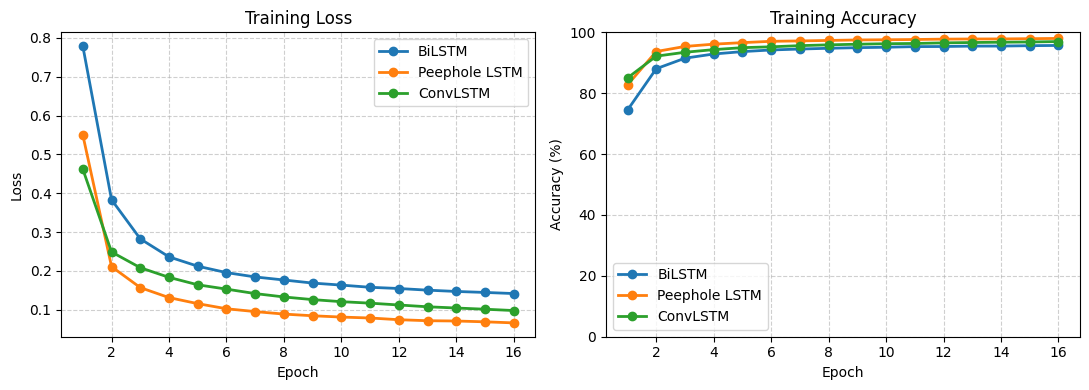

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for name, entry in models.items():
    train_losses = entry["train_losses"]
    train_accs = entry["train_accs"]

    epochs_range = range(1, len(train_losses) + 1)

    # Loss
    axes[0].plot(epochs_range, train_losses, marker="o", linewidth=2, label=name)

    # Accuracy
    axes[1].plot(epochs_range, [a * 100 for a in train_accs], marker="o", linewidth=2, label=name)

# Loss axis
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Accuracy axis
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close(fig)

Testing:

In [15]:
# Put models in evaluation mode
for entry in models.values():
    entry["model"].eval()

test_stats = {
    name: {"loss_sum": 0.0, "acc_sum": 0.0}
    for name in models
}

n = 0

with tc.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        B_curr = x_batch.size(0)
        n += B_curr

        x_seq = prepare_seq_input(x_batch)
        x_conv = prepare_conv_input(x_batch)

        for name, entry in models.items():
            model = entry["model"]

            if name == "ConvLSTM":
                logits, _ = model(x_conv)
            else:
                logits, _ = model(x_seq)

            if logits.ndim == 3:
                logits_last = logits[:, -1, :]
            else:
                logits_last = logits

            l = loss_fn(logits_last, y_batch)

            test_stats[name]["loss_sum"] += l.item() * B_curr
            test_stats[name]["acc_sum"] += batch_accuracy(logits_last, y_batch) * B_curr

# Compute final metrics
for name in models:
    test_loss = test_stats[name]["loss_sum"] / n
    test_acc = test_stats[name]["acc_sum"] / n

    print(
        f"{name:<14} | "
        f"Test loss {test_loss:.4f} | "
        f"Test acc {test_acc*100:.2f}%"
    )

BiLSTM         | Test loss 0.1588 | Test acc 95.36%
Peephole LSTM  | Test loss 0.0865 | Test acc 97.44%
ConvLSTM       | Test loss 0.1087 | Test acc 96.45%


## <u>Other LSTM Variants</u>

Over the years, several extensions of the LSTM architecture have been proposed. These variants typically modify how the gates interact with the memory cell or how the input is processed. While we only explored a few of them in this notebook, many other designs exist in the literature. Some notable examples include:

1) **Coupled Input–Forget Gate LSTM (CIFG)**, where the input and forget gates are linked through the relation $f_t = 1 - i_t$.

2) **LSTM with Projection (LSTMP)**, where the hidden state is projected to a lower-dimensional space $h_t = P \, \tilde{h}_t$.

3) **Grid LSTM**, which extends recurrence to multiple dimensions so that memory can propagate across different axes (e.g., spatial and temporal).

4) **Numerous other LSTM variants**, as the architecture has been extensively studied and modified over the years. In literature, **dozens of LSTM variants** have been proposed, exploring ideas such as modified gating mechanisms, normalization techniques, different memory update rules, and alternative recurrent connections. Surveys of recurrent neural networks often list **more than 30 distinct LSTM-style architectures**, reflecting the large research interest in improving memory, stability, and efficiency in such models.

In modern practice, many sequence modeling tasks have shifted toward **attention-based architectures**, such as Transformers, that we will visit in the future. Nevertheless, the LSTM and its variants still remain useful and relevant to modern real-world problems.

## <u>Optional Exploration and Homework</u>

The variants we implemented in this notebook are only a small subset of the many modifications that have been proposed for recurrent neural networks. A good way to deepen your understanding is to **experiment with the models and try modifying them yourself**. Some ideas you may want to explore:

---

**1. Implement and test another known LSTM variant**

Choose one of the variants of your choice and implement it yourself. After implementing it, compare its training behavior and final performance with the original LSTM (or another variant of your choice).

---

**2. Evaluate additional performance metrics**

So far we mainly examined **accuracy**. In many machine learning tasks it is also useful to evaluate metrics such as:

- **Precision**
- **Recall**
- **F1 score**

These metrics are especially useful when dealing with **imbalanced datasets**, where accuracy alone may be misleading.

---

**3. Create your own LSTM variant**

For example, you could experiment with:

- modifying connections between the cell state and gates  
- modifying activation functions  
- removing or tying certain gates together  
- any idea you can come up with

After implementing your idea, train, and tune a model and compare its performance with the original LSTM. What is a certain problem that your modified LSTM outperforms the original one and why?

---

These experiments are **not required**, but they are an excellent way to gain intuition about how recurrent neural networks behave in practice. Machine learning research often progresses through exactly this type of **careful experimentation and iteration**.

## <u>References</u>

**Core LSTM architecture**

- Hochreiter, S., & Schmidhuber, J. (1997).  
  *Long Short-Term Memory.*  
  Neural Computation, 9(8), 1735–1780.

**Bidirectional recurrent networks**

- Schuster, M., & Paliwal, K. K. (1997).  
  *Bidirectional Recurrent Neural Networks.*  
  IEEE Transactions on Signal Processing, 45(11), 2673–2681.

**Peephole LSTM**

- Gers, F. A., Schmidhuber, J., & Cummins, F. (2000).  
  *Learning to Forget: Continual Prediction with LSTM.*  
  Neural Computation, 12(10), 2451–2471.

**Convolutional LSTM**

- Shi, X., Chen, Z., Wang, H., Yeung, D.-Y., Wong, W., & Woo, W. (2015).  
  *Convolutional LSTM Network: A Machine Learning Approach for Precipitation Nowcasting.*  
  Advances in Neural Information Processing Systems (NeurIPS).

**LSTM variants overview**

- Greff, K., Srivastava, R. K., Koutník, J., Steunebrink, B. R., & Schmidhuber, J. (2017).  
  *LSTM: A Search Space Odyssey.*  
  IEEE Transactions on Neural Networks and Learning Systems.

---